In [17]:
# clone repo
!git clone https://github.com/irembuseozkose/QCNN-for-skin-cancer.git

# klasöre gir
%cd QCNN-for-skin-cancer

# python path ekle
import sys
sys.path.append("/content/QCNN-for-skin-cancer")

fatal: destination path 'QCNN-for-skin-cancer' already exists and is not an empty directory.
/content/QCNN-for-skin-cancer/QCNN-for-skin-cancer


In [18]:
!pip install -q qiskit qiskit-aer scikit-learn matplotlib pandas pillow pylatexenc

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
from pathlib import Path

DATA_PATH = Path("/content/drive/MyDrive/Projeler/SkinCancer/features_q_amplitude")

print(DATA_PATH)
print("Exists:", DATA_PATH.exists())

/content/drive/MyDrive/Projeler/SkinCancer/features_q_amplitude
Exists: True


In [21]:

import numpy as np
import matplotlib.pyplot as plt

from src.qcnn.datasets import load_all_splits, load_metadata
from src.qcnn.encoding import EncodingConfig, build_encoding_circuit
from src.qcnn.ansatz import build_parametric_qcnn_8q
from src.qcnn.model import QCNNModel, QCNNModelConfig
from src.qcnn.train import TrainConfig, fit

In [22]:
import numpy as np
import json

train = np.load(DATA_PATH / "train.npz")
val = np.load(DATA_PATH / "val.npz")
test = np.load(DATA_PATH / "test.npz")

x_train = train["x"]
y_train = train["y"]

x_val = val["x"]
y_val = val["y"]

x_test = test["x"]
y_test = test["y"]

with open(DATA_PATH / "metadata.json", "r") as f:
    metadata = json.load(f)

print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_val:", x_val.shape)
print("y_val:", y_val.shape)
print("x_test:", x_test.shape)
print("y_test:", y_test.shape)

x_train = x_train.astype(np.float64)
x_val = x_val.astype(np.float64)
x_test = x_test.astype(np.float64)

x_train = x_train / np.linalg.norm(x_train, axis=1, keepdims=True)
x_val = x_val / np.linalg.norm(x_val, axis=1, keepdims=True)
x_test = x_test / np.linalg.norm(x_test, axis=1, keepdims=True)

print(np.linalg.norm(x_train[0]))

x_train: (1567, 256)
y_train: (1567,)
x_val: (336, 256)
y_val: (336,)
x_test: (336, 256)
y_test: (336,)
1.0


In [23]:
print("Feature dim:", x_train.shape[1])
print("First sample norm:", np.linalg.norm(x_train[0]))
print("Unique labels:", np.unique(y_train))
print("Num classes in train:", len(np.unique(y_train)))

assert x_train.ndim == 2
assert x_train.shape[1] == 256, "8 qubit amplitude için feature_dim 256 bekleniyor"
assert np.isclose(np.linalg.norm(x_train[0]), 1.0, atol=1e-6), "İlk örnek L2-normalize değil"

Feature dim: 256
First sample norm: 1.0
Unique labels: [0 1 2 3 4 5 6 7 8]
Num classes in train: 9


Sample label: 1
Num qubits: 8


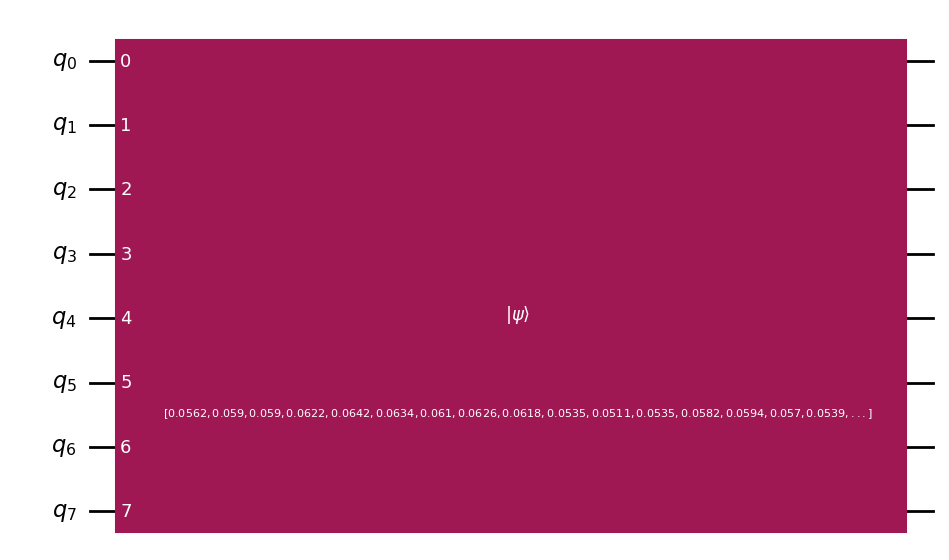

In [24]:
encoding_cfg = EncodingConfig(
    n_qubits=8,
    encoding_mode="amplitude",
    rotation_gate="ry",
    add_barriers=False,
)

x0 = x_train[0]
y0 = y_train[0]

encoding_circuit = build_encoding_circuit(x0, encoding_cfg)

print("Sample label:", y0)
print("Num qubits:", encoding_circuit.num_qubits)

encoding_circuit.draw("mpl")

Final active qubits: [3, 7]
Conv1 params: 24
Pool1 params: 12
Conv2 params: 12
Pool2 params: 6
Conv3 params: 6
Total trainable QCNN params: 60


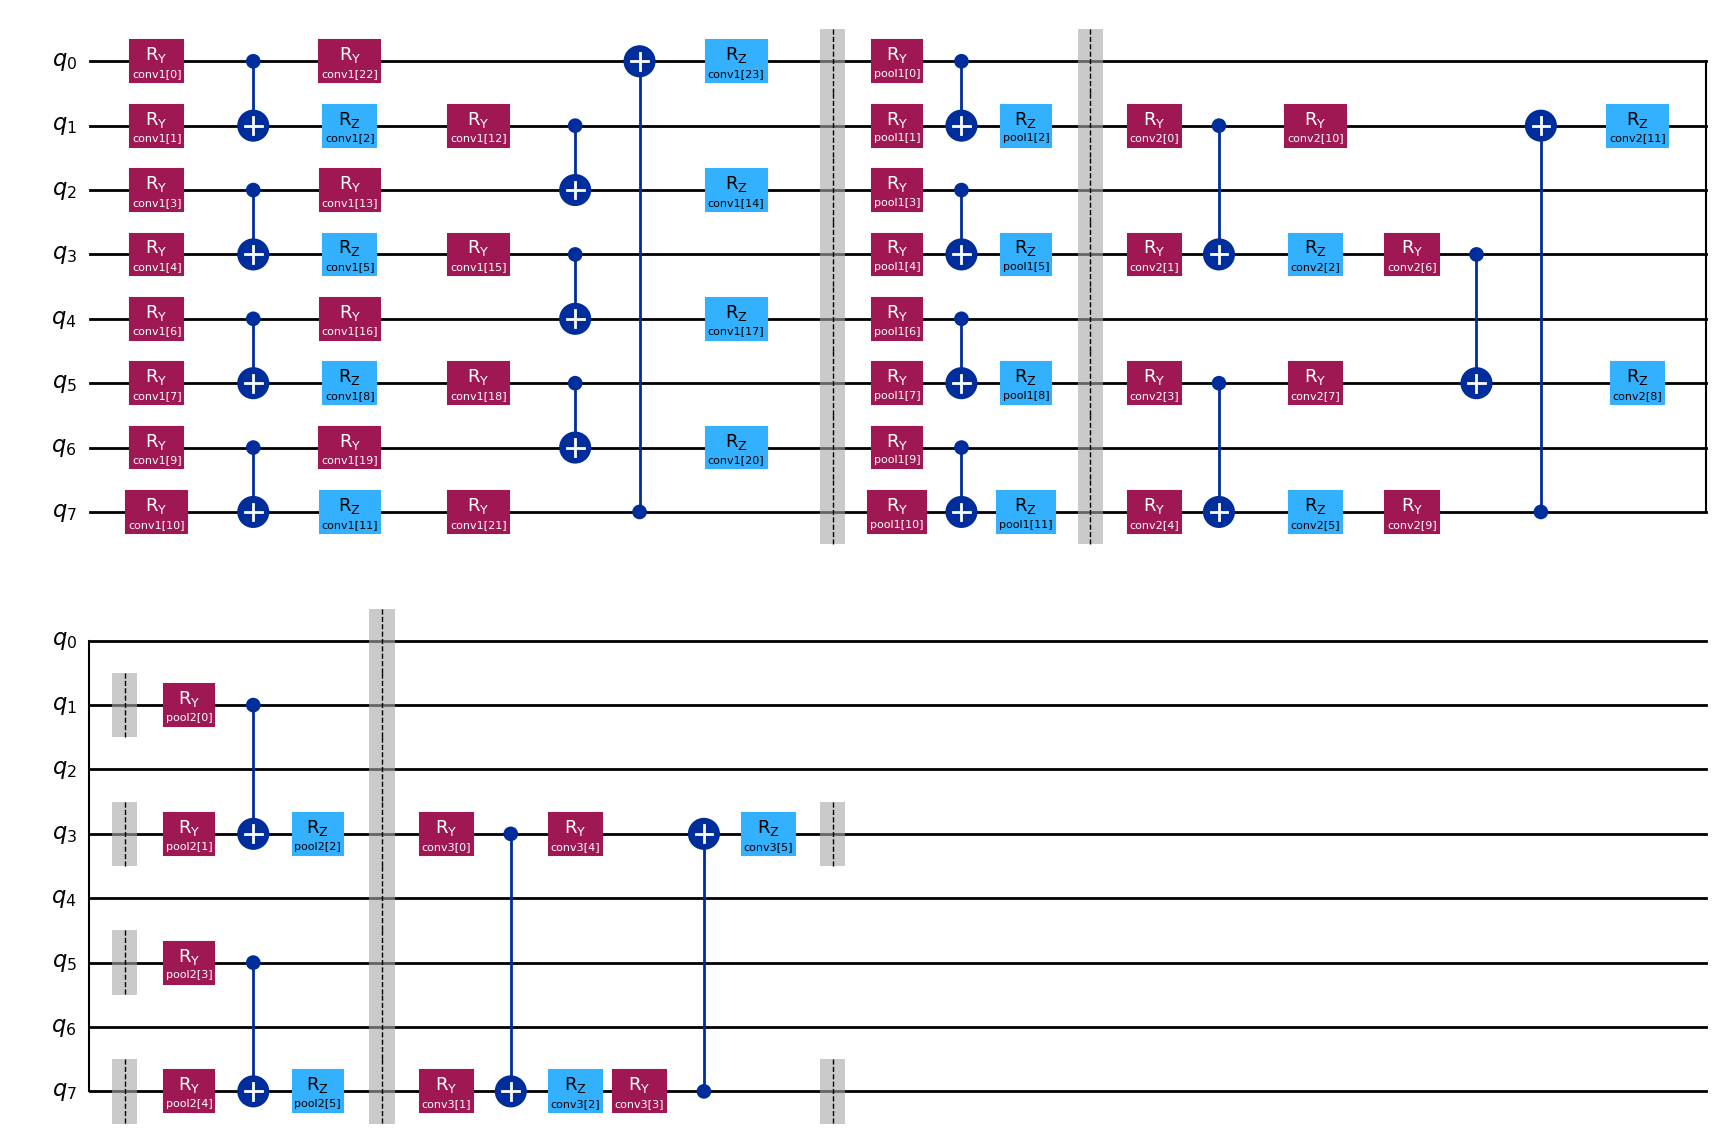

In [25]:
qcnn_circuit, qcnn_params, final_qubits = build_parametric_qcnn_8q(add_barriers=True)

print("Final active qubits:", final_qubits)
print("Conv1 params:", len(qcnn_params["conv1"]))
print("Pool1 params:", len(qcnn_params["pool1"]))
print("Conv2 params:", len(qcnn_params["conv2"]))
print("Pool2 params:", len(qcnn_params["pool2"]))
print("Conv3 params:", len(qcnn_params["conv3"]))
print("Total trainable QCNN params:", sum(len(v) for v in qcnn_params.values()))

qcnn_circuit.draw("mpl")

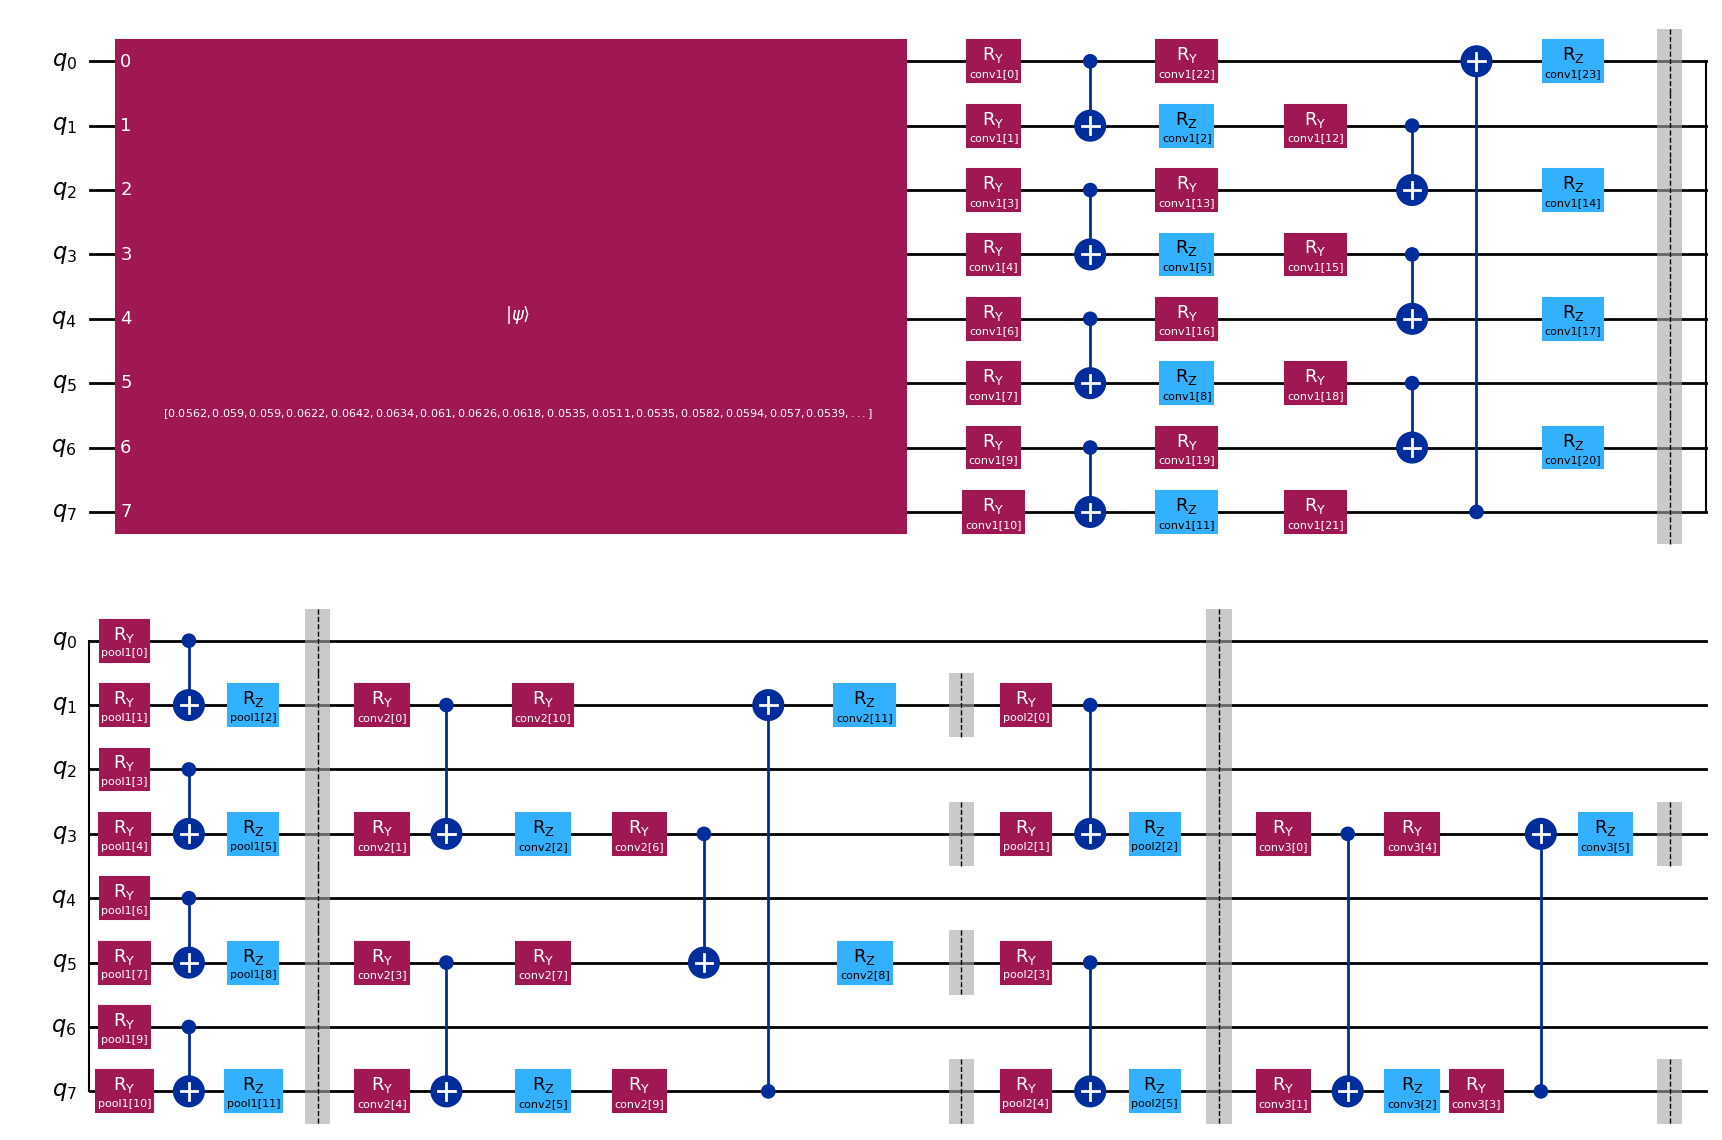

In [26]:
full_circuit = encoding_circuit.compose(qcnn_circuit)
full_circuit.draw("mpl")

In [27]:
model_cfg = QCNNModelConfig(
    n_qubits=8,
    add_barriers=False,
)

qcnn_model = QCNNModel(
    encoding_cfg=encoding_cfg,
    model_cfg=model_cfg,
)

print(qcnn_model.summary())

{'n_qubits': 8, 'encoding_mode': 'amplitude', 'rotation_gate': 'ry', 'n_trainable_params': 60, 'final_active_qubits': [3, 7], 'parameter_sizes': {'conv1': 24, 'pool1': 12, 'conv2': 12, 'pool2': 6, 'conv3': 6}}


In [28]:
theta = np.random.uniform(-0.1, 0.1, size=qcnn_model.n_trainable_params)

probs = qcnn_model.predict_probabilities_statevector(x0, theta)

print("Quantum output shape:", probs.shape)
print("Quantum output:", probs)
print("Sum:", probs.sum())

Quantum output shape: (4,)
Quantum output: [0.22751502 0.27813286 0.26500909 0.22934303]
Sum: 0.9999999999999993


In [29]:
N_TRAIN_SMALL = 64
N_VAL_SMALL = 32

x_train_small = x_train[:N_TRAIN_SMALL]
y_train_small = y_train[:N_TRAIN_SMALL]

x_val_small = x_val[:N_VAL_SMALL]
y_val_small = y_val[:N_VAL_SMALL]

print(x_train_small.shape, y_train_small.shape)
print(x_val_small.shape, y_val_small.shape)

(64, 256) (64,)
(32, 256) (32,)


In [30]:
cfg = TrainConfig(
    data_dir=DATA_PATH,

    n_qubits=8,
    encoding_mode="amplitude",
    rotation_gate="ry",
    add_barriers=False,

    n_classes=9,

    epochs=10,
    batch_size=8,
    seed=42,

    lr=1e-2,
    c=1e-1,

    head_init_scale=1e-2,

    max_train_samples=N_TRAIN_SMALL,
    max_val_samples=N_VAL_SMALL,

    checkpoint_dir=Path("/content/drive/MyDrive/Projeler/SkinCancer/outputs/checkpoints"),
    history_path=Path("/content/drive/MyDrive/Projeler/SkinCancer/outputs/train_history_amplitude.json"),
)

cfg

TrainConfig(data_dir=PosixPath('/content/drive/MyDrive/Projeler/SkinCancer/features_q_amplitude'), n_qubits=8, encoding_mode='amplitude', rotation_gate='ry', add_barriers=False, n_classes=9, epochs=10, batch_size=8, seed=42, lr=0.01, c=0.1, head_init_scale=0.01, max_train_samples=64, max_val_samples=32, checkpoint_dir=PosixPath('/content/drive/MyDrive/Projeler/SkinCancer/outputs/checkpoints'), history_path=PosixPath('/content/drive/MyDrive/Projeler/SkinCancer/outputs/train_history_amplitude.json'))

In [ ]:
import numpy as np

# float64 yap
x_train = x_train.astype(np.float64)
x_val = x_val.astype(np.float64)
x_test = x_test.astype(np.float64)

# tekrar normalize et
x_train = x_train / np.linalg.norm(x_train, axis=1, keepdims=True)
x_val = x_val / np.linalg.norm(x_val, axis=1, keepdims=True)
x_test = x_test / np.linalg.norm(x_test, axis=1, keepdims=True)

print("train norm:", np.linalg.norm(x_train[0]))
print("val norm:", np.linalg.norm(x_val[0]))
print("test norm:", np.linalg.norm(x_test[0]))

In [31]:
model, best_params, history = fit(cfg)

Training started
Train samples: 64
Val samples: 32
Test samples: 336
QCNN params: 60
Head params: 45
Total params: 105


QiskitError: 'Sum of amplitudes-squared is not 1, but 1.0000000227660553.'

In [ ]:
import pandas as pd

epochs_df = pd.DataFrame(history["epochs"])
epochs_df

In [ ]:
plt.plot(epochs_df["epoch"],epochs_df["train_loss"],label="train")
plt.plot(epochs_df["epoch"],epochs_df["val_loss"],label="val")
plt.legend()
plt.xlabel("epoch")
plt.ylabel("loss")
plt.show()

In [ ]:
plt.plot(epochs_df["epoch"],epochs_df["train_accuracy"],label="train")
plt.plot(epochs_df["epoch"],epochs_df["val_accuracy"],label="val")
plt.legend()
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.show()

In [ ]:
y_pred = np.array([model.predict_class(x,best_params) for x in x_test])

In [ ]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

print("accuracy:",accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))